In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import gymnasium as gym


import matplotlib.pyplot as plt
import torch
from tensorboard.backend.event_processing import event_accumulator
from pathlib import Path
from stable_baselines3 import DQN as SB3DQN

from highway.scripts.environment import get_env, ConfigType
from highway.scripts.run import eval_agent, run_one_episode
from highway.scripts.utils.agents import SB3GreedyAgent
from highway.scripts.utils.paths import get_training_paths
from highway.scripts.utils.plotting import (
    plot_losses,
    plot_rewards_lengths,
    plot_train_rewards_lengths,
)
from highway.scripts.utils.statistics import compute_confidence_interval

from copy import deepcopy

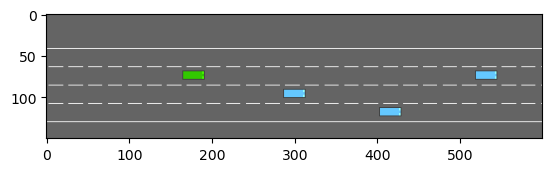

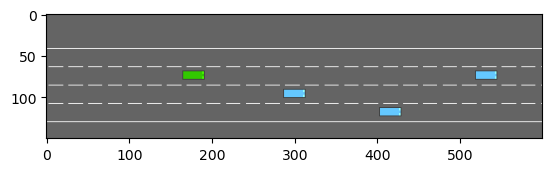

In [3]:
env = get_env(seed=1, config_type=ConfigType.SHARED_CORE)
env_CNN = get_env(seed=1, config_type=ConfigType.TEST_CNN)
# Show the environment
plt.imshow(env.render())
plt.show()
plt.imshow(env_CNN.render())
plt.show()

## Evaluation setup

In [4]:
eval_seeds = list(range(50))

## Baseline

### Random Agent

In [8]:
from highway.models.random_agent.random_agent import RandomAgent

agent = RandomAgent(env.observation_space, env.action_space)

rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 30/30 [01:35<00:00,  3.20s/ep]


In [9]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 9.15 ± 2.29 (95% CI: [6.87, 11.44])
Length: 12.27 ± 3.05 (95% CI: [9.22, 15.32])


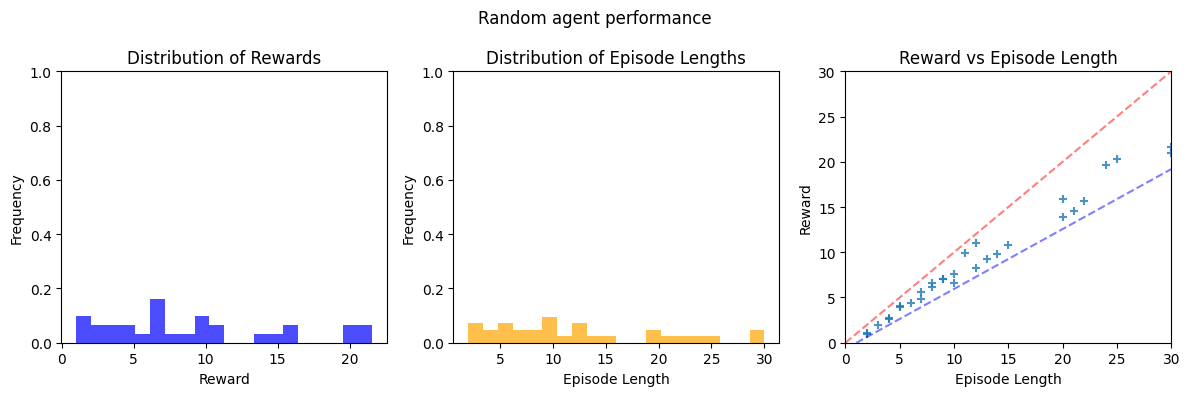

In [10]:
plot_rewards_lengths(rewards, lengths, title="Random agent performance")

### Idle agent

In [11]:
from highway.models.idle_agent.idle_agent import IdleAgent

agent = IdleAgent(env.observation_space, env.action_space)

rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 30/30 [02:25<00:00,  4.84s/ep]


In [12]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 14.67 ± 2.61 (95% CI: [12.07, 17.28])
Length: 19.17 ± 3.19 (95% CI: [15.98, 22.35])


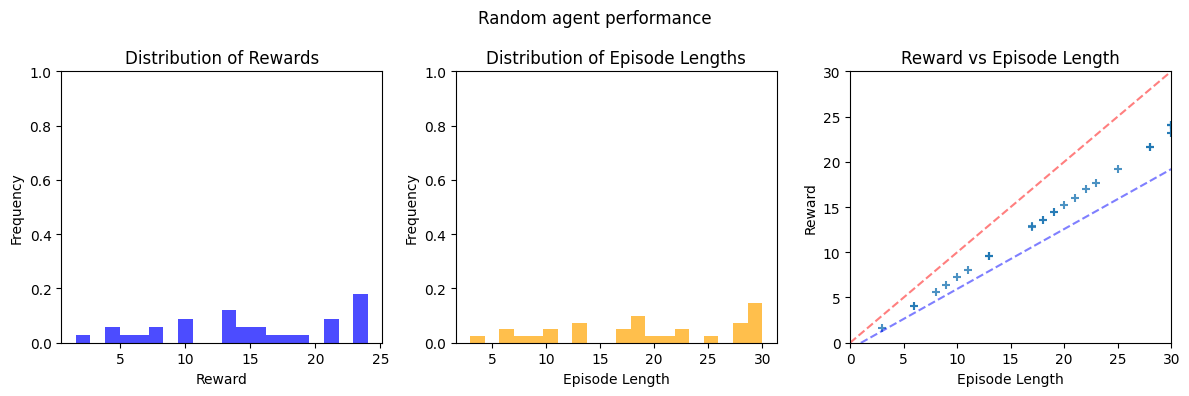

In [13]:
plot_rewards_lengths(rewards, lengths, title="Random agent performance")

## DQN Agent

In [14]:
from highway.models.dqn.dqn import DQN

action_space = env.action_space
observation_space = env.observation_space

gamma = 0.9
batch_size = 64
buffer_capacity = 10_000
update_target_every = 200

epsilon_start = 0.95
decrease_epsilon_factor = 50
epsilon_min = 0.05

learning_rate = 5e-4

arguments = (action_space,
            observation_space,
            gamma,
            batch_size,
            buffer_capacity,
            update_target_every, 
            epsilon_start, 
            decrease_epsilon_factor, 
            epsilon_min,
            learning_rate,
        )

dqn_base_agent = DQN(*arguments)

### Identical environment for training and evaluation

In [16]:
date_str = "20260410_152850"

best_model_path, losses, train_rewards, train_lengths, ep_paths = get_training_paths(date_str)

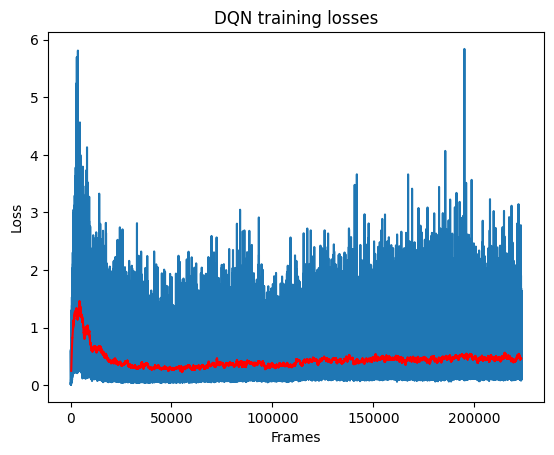

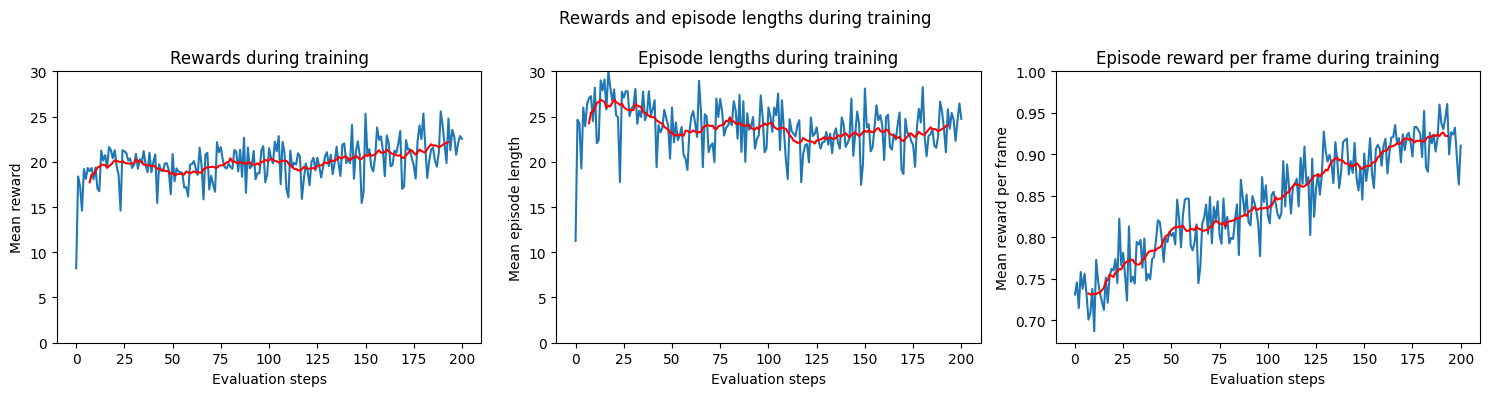

In [17]:
plot_losses(losses, nb_smoothen=500, title="DQN training losses")
plot_train_rewards_lengths(train_rewards, train_lengths, nb_smoothen=15)

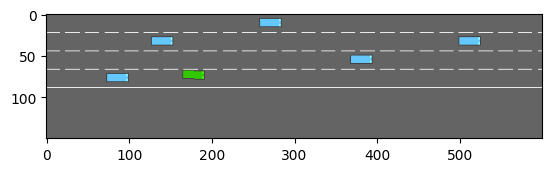

Episode reward=29.54, length=30


In [18]:
agent = deepcopy(dqn_base_agent)
agent.q_net.load_state_dict(torch.load(best_model_path))

reward, length = run_one_episode(env, agent, display=True)

In [19]:
rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 30/30 [03:03<00:00,  6.11s/ep]


In [20]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 21.69 ± 2.99 (95% CI: [18.70, 24.68])
Length: 23.83 ± 3.15 (95% CI: [20.69, 26.98])


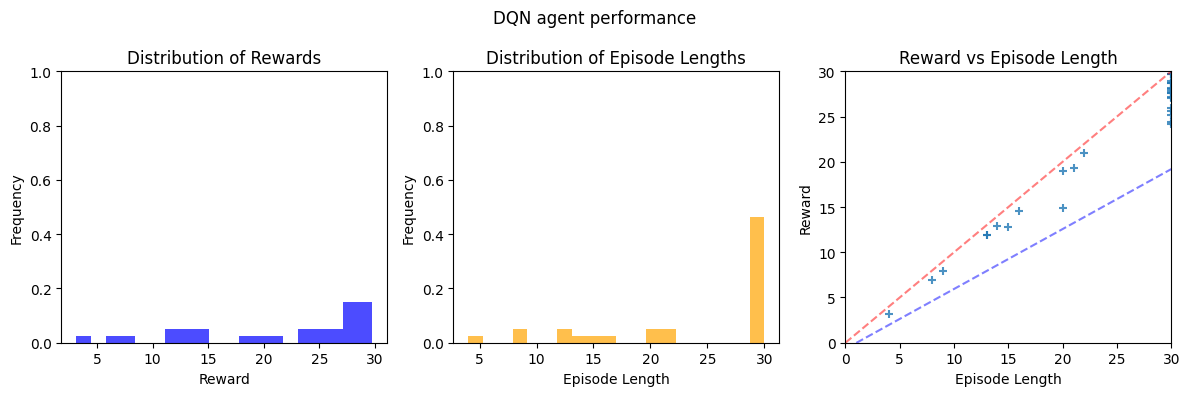

In [21]:
plot_rewards_lengths(rewards, lengths, title="DQN agent performance")

### Different environment between training and evaluation

In [22]:
date_str = "20260410_192141"

best_model_path, losses, train_rewards, train_lengths, ep_paths = get_training_paths(date_str)

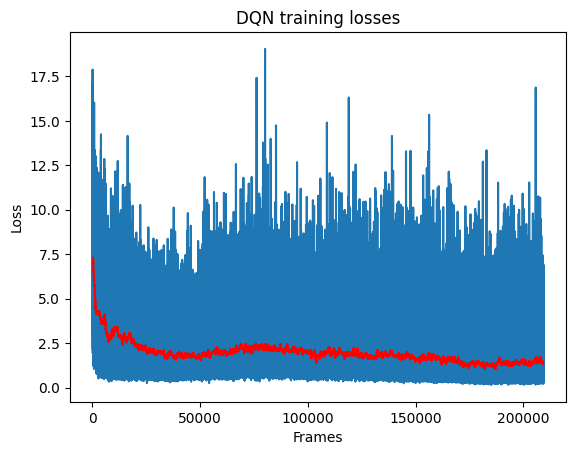

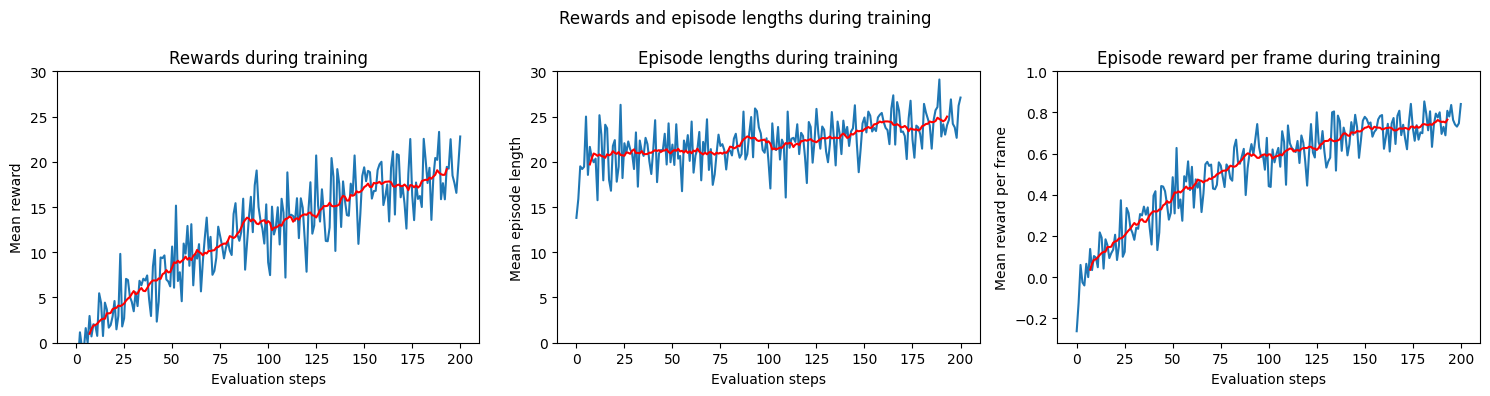

In [23]:
plot_losses(losses, nb_smoothen=500, title="DQN training losses")
plot_train_rewards_lengths(train_rewards, train_lengths, nb_smoothen=15)

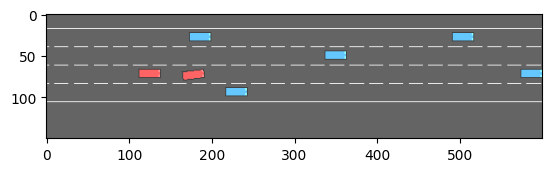

Episode reward=23.95, length=25


In [24]:
agent = deepcopy(dqn_base_agent)
agent.q_net.load_state_dict(torch.load(best_model_path))

reward, length = run_one_episode(env, agent, display=True)

In [25]:
rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 30/30 [02:53<00:00,  5.77s/ep]


In [26]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 21.40 ± 3.40 (95% CI: [18.00, 24.80])
Length: 22.63 ± 3.39 (95% CI: [19.24, 26.03])


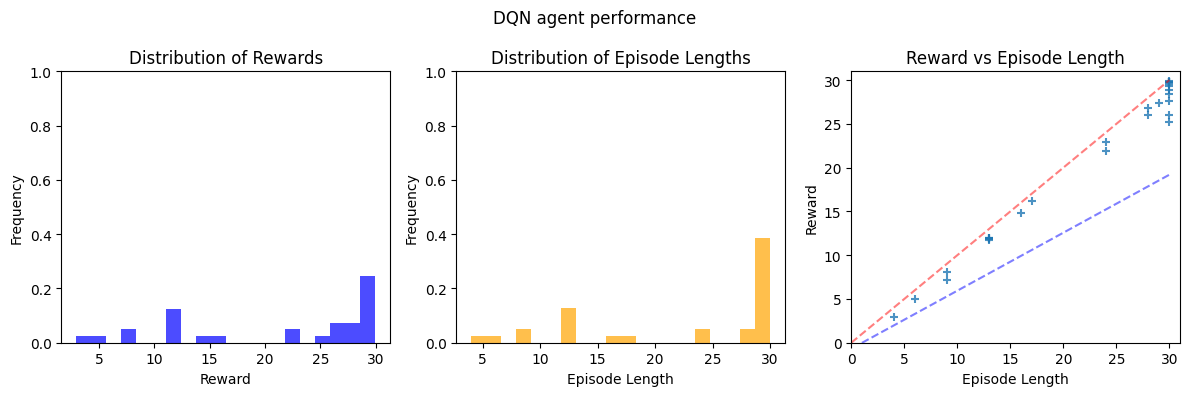

In [29]:
plot_rewards_lengths(rewards, lengths, title="DQN agent performance")

# CNN_DQN ANLYSIS

In [8]:
OUTPUT_ROOT = Path("outputs_cnn_dqn")
EVAL_CURVES_PATH = OUTPUT_ROOT / "eval_curves.npz"
EVAL_LOGS_PATH = OUTPUT_ROOT / "eval_logs" / "evaluations.npz"
BEST_MODEL_PATH = OUTPUT_ROOT / "best_model" / "best_model.zip"
REF_BEST_MODEL_PATH = OUTPUT_ROOT / "REF_BEST.zip"
FINAL_MODEL_PATH = OUTPUT_ROOT / "model.zip"
TB_ROOT = OUTPUT_ROOT / "tb"
EVENT_PATH = TB_ROOT / "cnn_dqn_20260412_225615_1" / "events.out.tfevents.1776027382.LAPTOP-DOH1GCOI.2816.0"
eval_data = np.load(EVAL_CURVES_PATH)
timesteps = eval_data["timesteps"]
mean_rewards = eval_data["mean_rewards"]
mean_ep_lengths = eval_data["mean_ep_lengths"]

In [9]:
event_file = EVENT_PATH
ea = event_accumulator.EventAccumulator(str(event_file))
ea.Reload()
print("Available scalar tags in tensor board:", ea.Tags().get("scalars", []))

Available scalar tags in tensor board: ['rollout/exploration_rate', 'time/fps', 'train/learning_rate', 'train/loss', 'eval/mean_ep_length', 'eval/mean_reward']


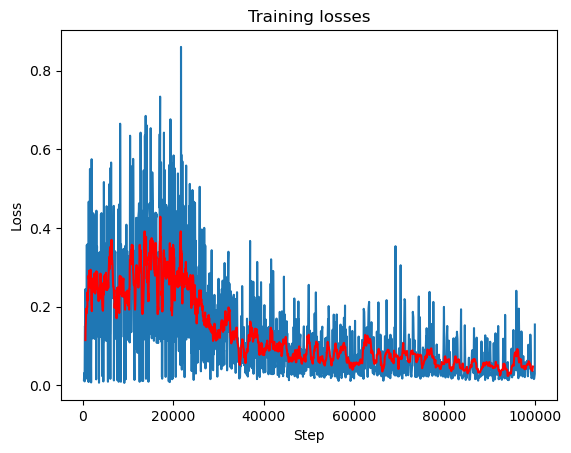

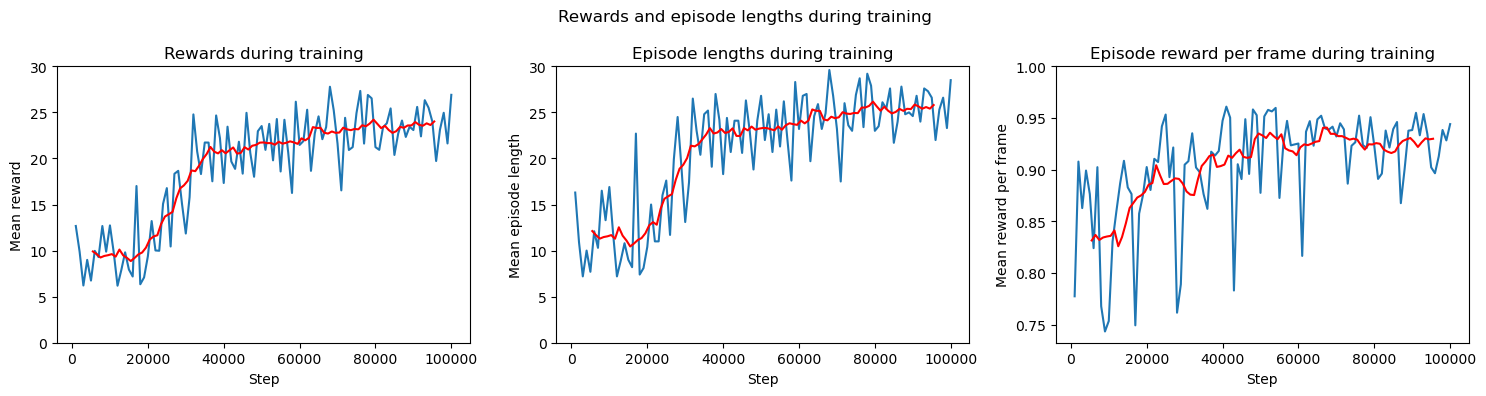

In [10]:
events = ea.Scalars("train/loss")
values = np.array([event.value for event in events], dtype=float)
plot_losses(values, nb_smoothen=10, title="Training losses", x_values=[event.step for event in events])
plot_train_rewards_lengths(mean_rewards, mean_ep_lengths, nb_smoothen=10, x_values=timesteps)

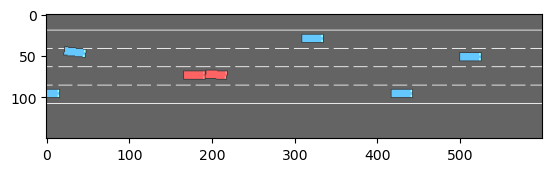

Episode reward=7.95, length=9


In [24]:
sb3_model = SB3DQN.load(
    str(BEST_MODEL_PATH),
    device="cpu",
    custom_objects={"buffer_size": 1},
)
agent = SB3GreedyAgent(sb3_model)

reward, length = run_one_episode(env_CNN, agent, display=True, make_deep_copy=False)

In [22]:
rewards, lengths = eval_agent(env_CNN, agent, seeds=eval_seeds, show_progress=True, make_deep_copy=False)

Evaluating: 100%|██████████| 50/50 [07:10<00:00,  8.60s/ep]


In [18]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 22.93 ± 2.32 (95% CI: [20.61, 25.26])
Length: 24.82 ± 2.39 (95% CI: [22.43, 27.21])


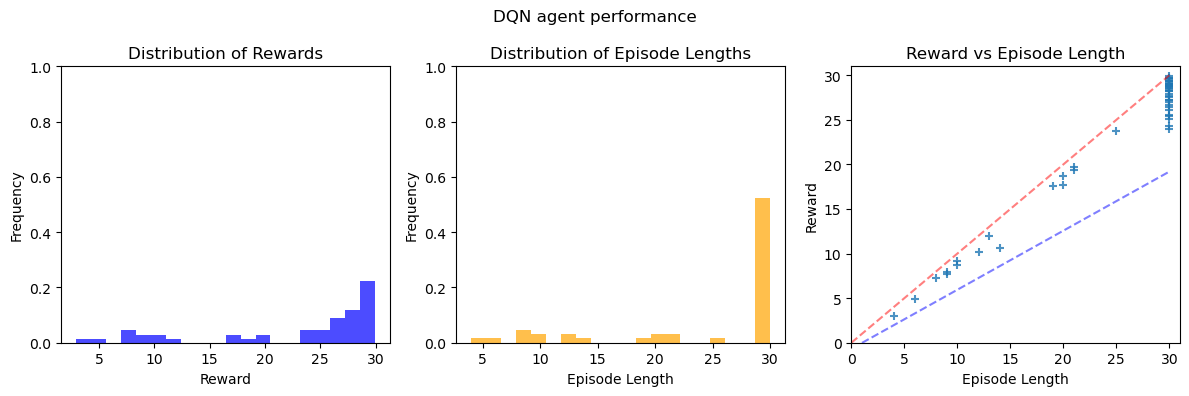

In [19]:
plot_rewards_lengths(rewards, lengths, title="DQN agent performance")